In [4]:
import numpy as np
import pandas as pd
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import collections
import itertools
import seaborn as sns
import tweepy
import datetime
import nltk
from nltk.corpus import stopwords
from PIL import Image
import datetime
from afinn import Afinn
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer 
from sklearn.feature_extraction.text import TfidfVectorizer
import operator
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from networkx.drawing.nx_agraph import graphviz_layout
import nltk

In [3]:
df = pd.read_excel('C:/Users/jwan0/Youtubecrawl_SW1117.xlsx')

df.head()

,Unnamed: 0,id,content of comments,Translation
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting: anne hathaway nailing e...
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,..."


In [4]:
df = df.astype('string')
df.dtypes

Unnamed: 0             string
id                     string
content of comments    string
Translation            string
dtype: object

In [5]:
df['Translation'] = df['Translation'].astype(str).str.lower()
df.head()

,Unnamed: 0,id,content of comments,Translation
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting: anne hathaway nailing e...
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,..."


In [6]:
from nltk.tokenize import RegexpTokenizer

regexp = RegexpTokenizer('\w+')

df['text_token']=df['Translation'].apply(regexp.tokenize)
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[i, m, not, sure, how, any, other, country, s,..."
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[the, grand, tour, is, only, a, fraction, of, ..."
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting: anne hathaway nailing e...,"[the, paradox, of, acting, anne, hathaway, nai..."
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, is, just, phenomenon, in, everything, i..."
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, on, the, verge, of, laughing, to, hi..."


In [6]:
stopwords = nltk.corpus.stopwords.words("english")

# Extend the list with your own custom stopwords
my_stopwords = ['https', 'and', 'this','from','you','that','for','was','are','can','but','all','who','what','where','your','really',
                'made', 'well', 'anyone','guys','name','much', 'put','ever','could', 'one', 'done','come','www','may', 'hey', 'chan',
                'someday', 'still','yet','somehow','first', 'yoooo', '2021', '2020', 'truly', '2019','also', 'degree', 'units', 'skip', 
                'hello', 'soon', 'even', 'really', 'going','greeting', 'come', 'next','looks', 'ahhhh', 'desu', 'get', 'got', 'guy', 
                'make', 'qua','watashi', 'okay', 'yuri', 'com', 'back', 'wait', 'thought','past', 'would', 'lot', 'let', 'though','take',
                "br", 'ji', '18', 'kuvaev', 'sergey' , 'sam', 'yes', 'right', 'single', 'many', '170', '102', 'whats', '100', 'mrs',
                'always', 'haha', 'two', 'yeah', 'anybody', 'thing', 'whole', 'rrulong', 'tennis', 'meh', 'mix', 'hard', 'wtf',
                'shalom', 'samira', 'ann', 'john', 'cena', 'damn', 'zmm']

stopwords.extend(my_stopwords)

In [8]:
df['text_token'] = df['text_token'].apply(lambda x: [item for item in x if item not in stopwords])
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, beat]"
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te..."
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting: anne hathaway nailing e...,"[paradox, acting, anne, hathaway, nailing, eve..."
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]"
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]"


In [9]:
df['text_string'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if len(item)>2]))

df.head()

,Unnamed: 0,id,content of comments,Translation,text_token,text_string
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, beat]",sure country tourism board beat
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting: anne hathaway nailing e...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing


In [10]:
df[['Translation', 'text_token', 'text_string']].head()

,Translation,text_token,text_string
0,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, beat]",sure country tourism board beat
1,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...
2,the paradox of acting: anne hathaway nailing e...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...
3,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love
4,"federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing


In [11]:
#nltk.download('punkt')

#Create a list of all words
all_words = ' '.join([word for word in df['text_string']])

#Tokenize all_words
tokenized_words = nltk.tokenize.word_tokenize(all_words)

#Create a frequency distribution which records the number of times each word has occurred:

from nltk.probability import FreqDist

fdist = FreqDist(tokenized_words)
fdist

FreqDist({'roger': 81, 'switzerland': 76, 'anne': 56, 'love': 30, 'federer': 28, 'great': 28, 'beautiful': 26, 'hathaway': 25, 'views': 24, 'tour': 22, ...})

In [12]:
df['text_string_fdist'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if fdist[item] >= 1 ]))

In [13]:
df[['Translation','text_token', 'text_string', 'text_string_fdist']].head()

,Translation,text_token,text_string,text_string_fdist
0,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, beat]",sure country tourism board beat,sure country tourism board beat
1,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...
2,the paradox of acting: anne hathaway nailing e...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...
3,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love,anne phenomenon everything love
4,"federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing,federer verge laughing lines funny thing


In [14]:
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word,pos='v') for word in words]
    words = [lemmatizer.lemmatize(word,pos='n') for word in words]
    return ' '.join(words)
df['text_string_lem'] = df['text_string_fdist'].apply(lemmatize_words)

In [15]:
df['is_equal']= (df['text_string_fdist']==df['text_string_lem'])

In [16]:
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, beat]",sure country tourism board beat,sure country tourism board beat,sure country tourism board beat,True
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer term sce...,False
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting: anne hathaway nailing e...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,paradox act anne hathaway nail every beat perf...,False
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love,anne phenomenon everything love,anne phenomenon everything love,True
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing,federer verge laughing lines funny thing,federer verge laugh line funny thing,False


In [17]:
df = df.dropna()
df.head()

,Unnamed: 0,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,1,Traveling with Kristin,I’m not sure how any other country’s tourism b...,i’m not sure how any other country’s tourism b...,"[sure, country, tourism, board, beat]",sure country tourism board beat,sure country tourism board beat,sure country tourism board beat,True
1,2,Sylvia Michel Photography - Switzerland's Best,The Grand Tour is only a fraction of what Swit...,the grand tour is only a fraction of what swit...,"[grand, tour, fraction, switzerland, offer, te...",grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer terms sc...,grand tour fraction switzerland offer term sce...,False
2,3,Kingsley CY,The paradox of acting:Anne Hathaway nailing ev...,the paradox of acting: anne hathaway nailing e...,"[paradox, acting, anne, hathaway, nailing, eve...",paradox acting anne hathaway nailing every bea...,paradox acting anne hathaway nailing every bea...,paradox act anne hathaway nail every beat perf...,False
3,4,Suradech Singhanat,Anne is just phenomenon in everything. I love ...,anne is just phenomenon in everything. i love ...,"[anne, phenomenon, everything, love]",anne phenomenon everything love,anne phenomenon everything love,anne phenomenon everything love,True
4,5,dj7oya,"Federer on the verge of laughing to his lines,...","federer on the verge of laughing to his lines,...","[federer, verge, laughing, lines, funny, thing]",federer verge laughing lines funny thing,federer verge laughing lines funny thing,federer verge laugh line funny thing,False


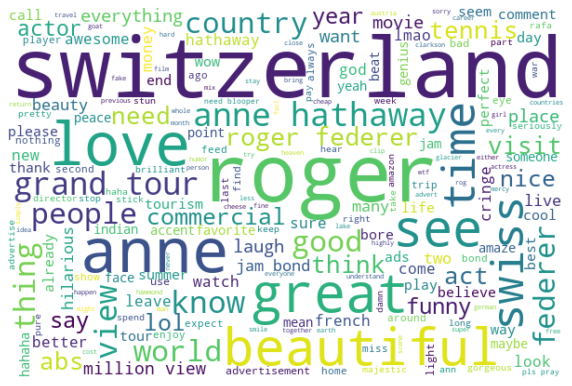

In [18]:
from wordcloud import WordCloud

all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(width=600, 
                     height=400, 
                     random_state=2, 
                     background_color='white', 
                     max_font_size=100).generate(all_words_lem)


plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

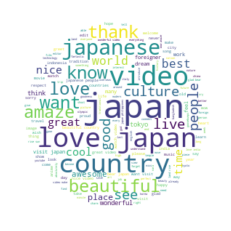

In [148]:
x, y = np.ogrid[:300, :300]
mask = (x - 150) ** 2 + (y - 150) ** 2 > 130 ** 2
mask = 255 * mask.astype(int)

wc = WordCloud(background_color="white", repeat=True, mask=mask)
wc.generate(all_words_lem)

plt.axis("off")
plt.imshow(wc, interpolation="bilinear");

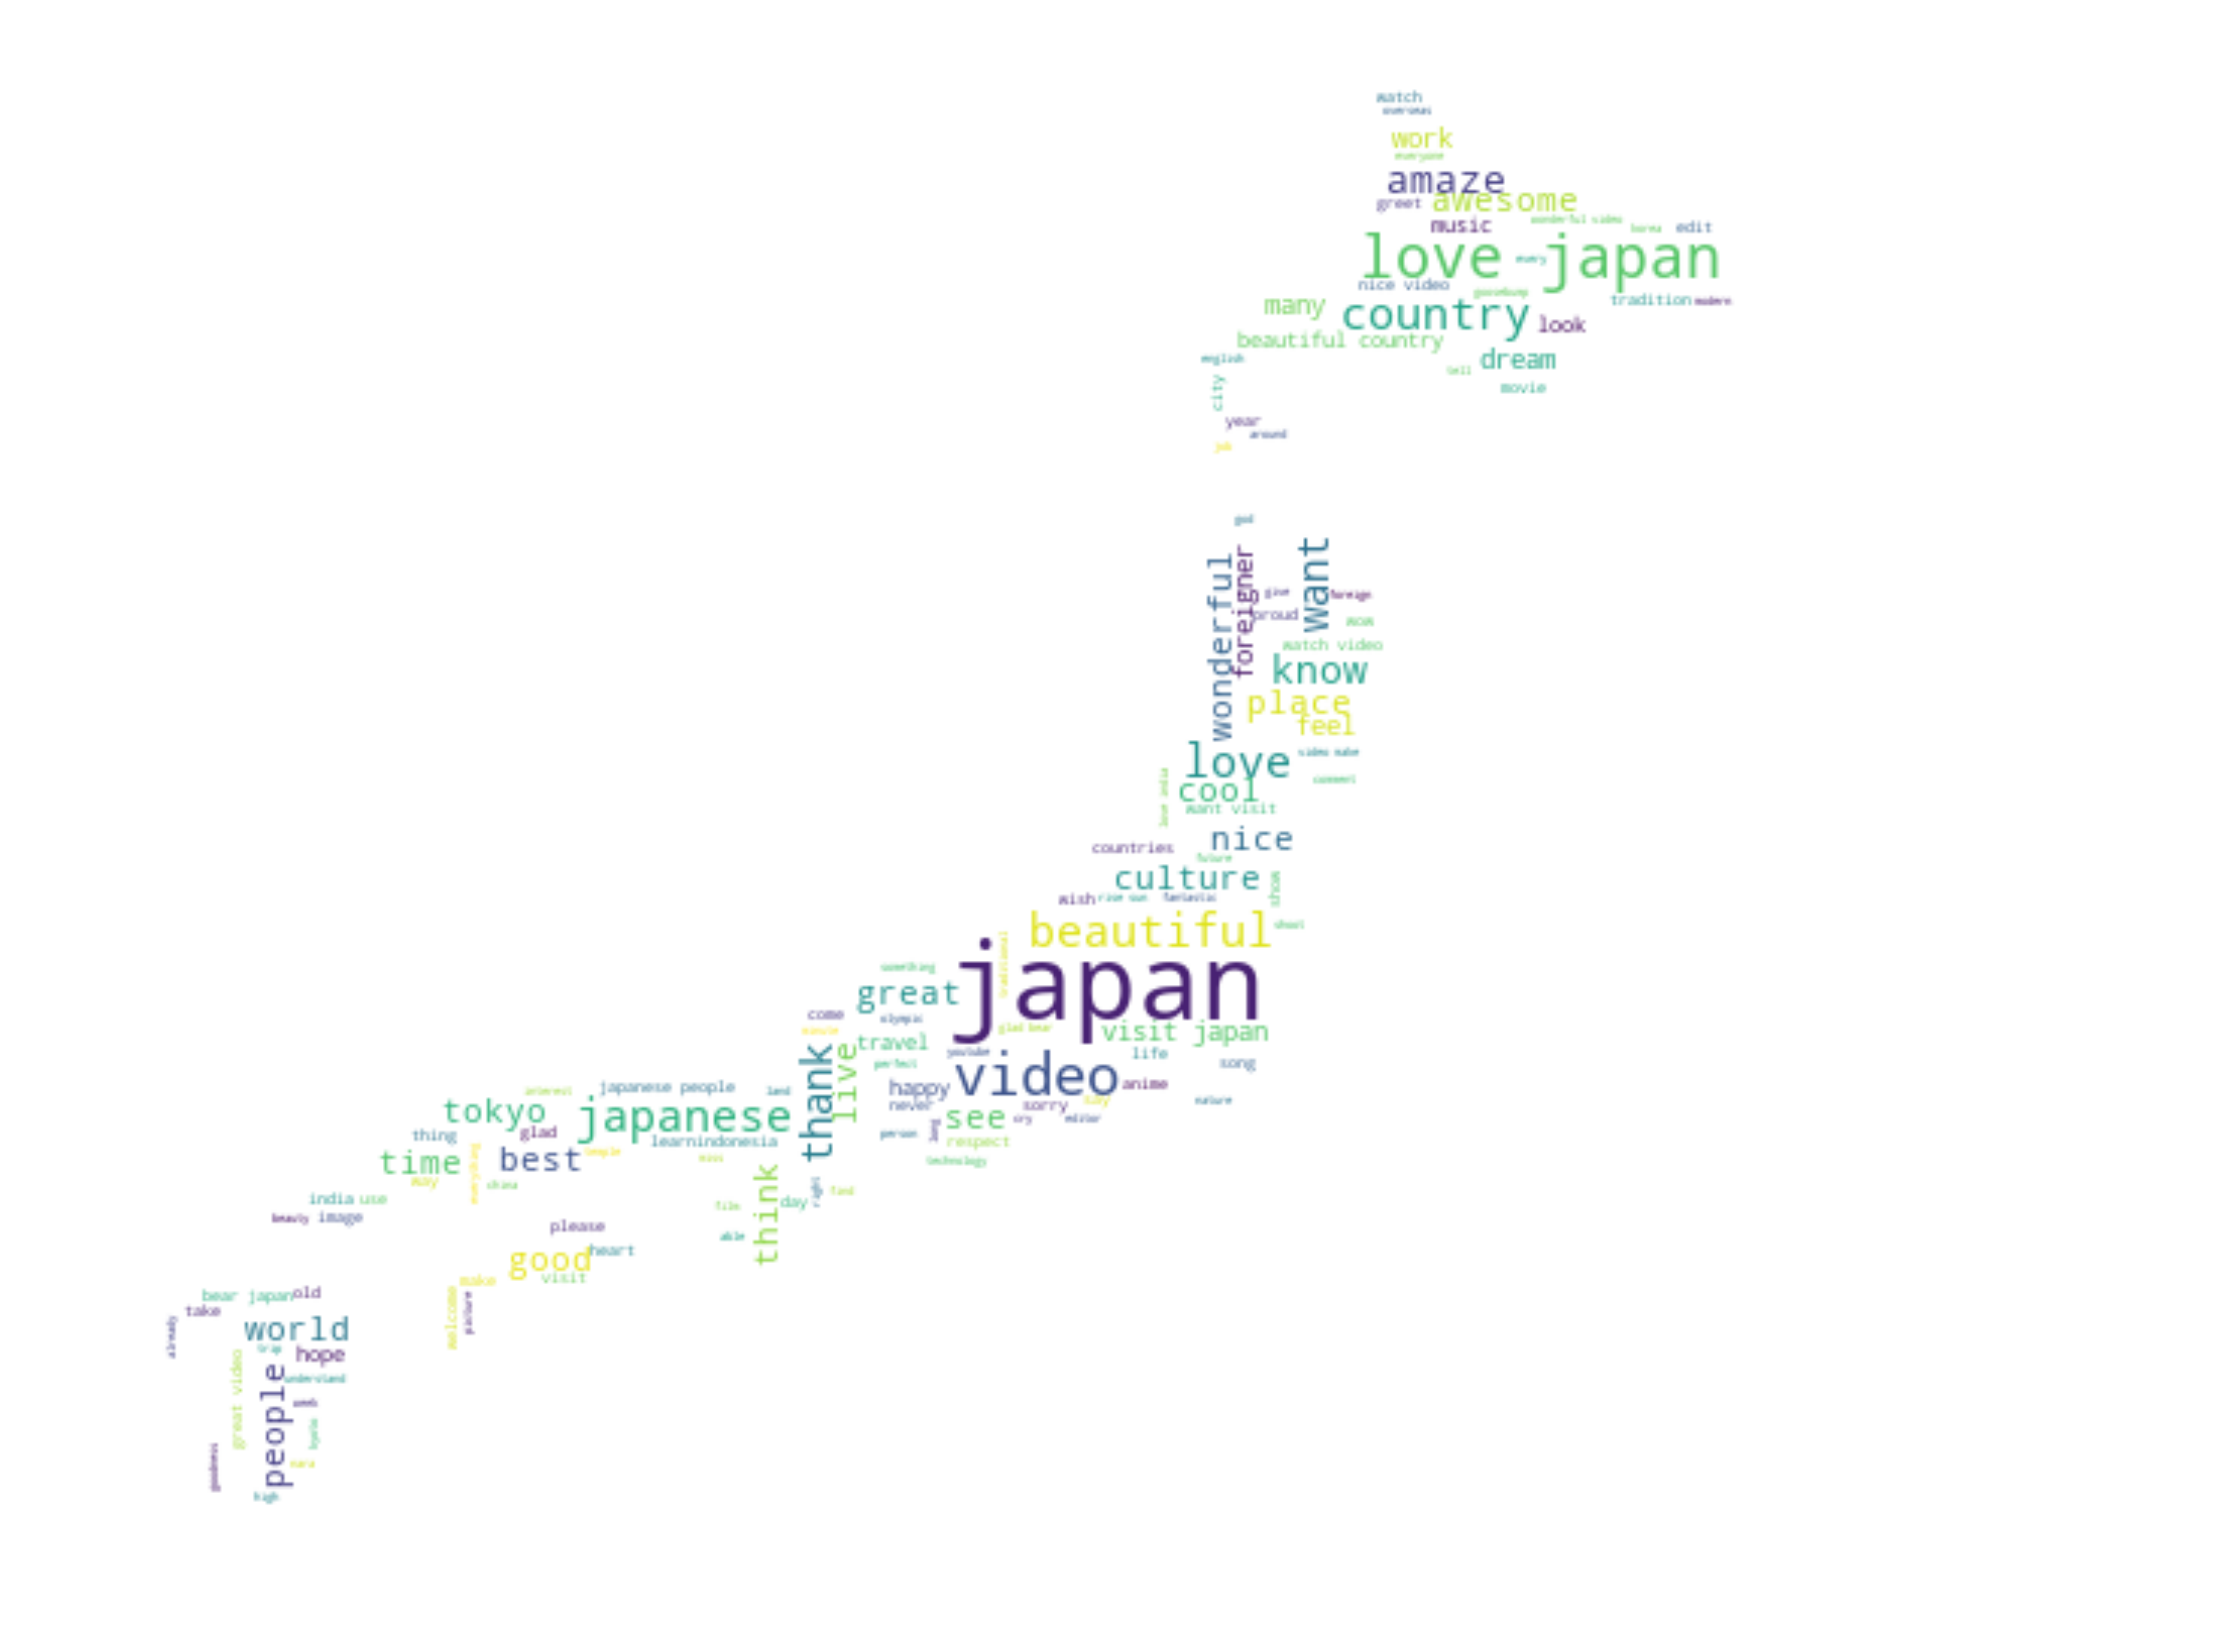

In [320]:
from wordcloud import WordCloud
mask = np.array(Image.open(r'C:\Users\jwan0\Geomap-asia-Japan.png'))
all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(random_state=2, 
                     background_color='white', 
                     mask = mask,
                     width = mask.shape[1],
                     height = mask.shape[0],
                     max_font_size=500).generate(all_words_lem)


plt.figure(figsize=(100, 80))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

In [5]:
#Word frequency list

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

words = nltk.word_tokenize(all_words_lem)
fd = FreqDist(words)

NameError: name 'all_words_lem' is not defined

In [322]:
fd.most_common(200)

[('japan', 737),
 ('love', 316),
 ('video', 240),
 ('country', 137),
 ('japanese', 131),
 ('beautiful', 129),
 ('like', 112),
 ('want', 95),
 ('thank', 76),
 ('amaze', 75),
 ('people', 74),
 ('know', 68),
 ('visit', 64),
 ('great', 60),
 ('culture', 52),
 ('nice', 51),
 ('good', 51),
 ('see', 49),
 ('wonderful', 49),
 ('live', 45),
 ('world', 43),
 ('best', 41),
 ('cool', 39),
 ('time', 38),
 ('place', 36),
 ('watch', 36),
 ('awesome', 36),
 ('think', 35),
 ('tokyo', 34),
 ('feel', 31),
 ('bear', 31),
 ('music', 31),
 ('india', 30),
 ('many', 30),
 ('wow', 30),
 ('work', 30),
 ('make', 29),
 ('dream', 27),
 ('look', 27),
 ('happy', 26),
 ('hope', 25),
 ('foreigners', 24),
 ('glad', 24),
 ('travel', 24),
 ('countries', 23),
 ('come', 21),
 ('say', 21),
 ('please', 21),
 ('edit', 20),
 ('use', 20),
 ('respect', 19),
 ('never', 18),
 ('land', 18),
 ('proud', 17),
 ('image', 17),
 ('videos', 17),
 ('welcome', 16),
 ('show', 16),
 ('job', 16),
 ('learn', 15),
 ('greet', 15),
 ('wish', 15),


In [48]:
word_rank = fd.most_common(200)

WR = pd.DataFrame(word_rank)

WR.to_excel('Word_top_200_sw.xlsx')

In [3]:
top_20 = fd.most_common(20)

fdist = pd.Series(dict(top_20))

NameError: name 'fd' is not defined

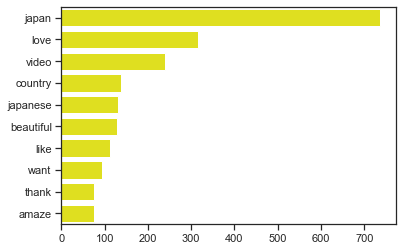

In [324]:
sns.set_theme(style="ticks")

sns.barplot(y=fdist.index, x=fdist.values, color='yellow');

In [325]:
from nltk.sentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['polarity'] = df['text_string_lem'].apply(lambda x: analyzer.polarity_scores(x))
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,polarity
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy,love japan italy,love japan italy,True,"{'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'comp..."
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False,"{'neg': 0.046, 'neu': 0.827, 'pos': 0.127, 'co..."
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india,japan wonder love india,japan wonder love india,True,"{'neg': 0.0, 'neu': 0.417, 'pos': 0.583, 'comp..."
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False,"{'neg': 0.0, 'neu': 0.792, 'pos': 0.208, 'comp..."
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watch video make feel happy bear beautiful cou...,False,"{'neg': 0.0, 'neu': 0.428, 'pos': 0.572, 'comp..."


In [326]:
df = pd.concat(
    [df.drop(['polarity'], axis=1), df['polarity'].apply(pd.Series)], axis=1)
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy,love japan italy,love japan italy,True,0.000,0.323,0.677,0.6369
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False,0.046,0.827,0.127,0.7506
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india,japan wonder love india,japan wonder love india,True,0.000,0.417,0.583,0.6369
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False,0.000,0.792,0.208,0.6369
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watch video make feel happy bear beautiful cou...,False,0.000,0.428,0.572,0.9918


In [327]:
df['sentiment'] = df['compound'].apply(lambda x: 'positive' if x >0 else 'neutral' if x==0 else 'negative')
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, italy]",love japan italy,love japan italy,love japan italy,True,0.000,0.323,0.677,0.6369,positive
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False,0.046,0.827,0.127,0.7506,positive
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love, india]",japan wonder love india,japan wonder love india,japan wonder love india,True,0.000,0.417,0.583,0.6369,positive
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False,0.000,0.792,0.208,0.6369,positive
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, makes, feel, happy, born, be...",watching video makes feel happy born beautiful...,watching video makes feel happy born beautiful...,watch video make feel happy bear beautiful cou...,False,0.000,0.428,0.572,0.9918,positive


In [328]:
df.loc[df['compound'].idxmax()].values
print()
# Tweet with highest negative sentiment 
# ...seems to be a case of wrong classification because of the word "deficit"
df.loc[df['compound'].idxmin()].values

array(['  bni',
       '日本の悪いところと言われる長時間労働や自殺率。まさに自分が精神科にかかり続けてる社畜だけどこの国を恨んだことは一度もない',
       "long working hours and suicide rate are said to be bad points in japan. i'm a social slave who keeps going to a psychiatrist, but i've never held a grudge against this country.",
       list(['long', 'working', 'hours', 'suicide', 'rate', 'said', 'bad', 'points', 'japan', 'social', 'slave', 'keeps', 'psychiatrist', 'never', 'held', 'grudge', 'country']),
       'long working hours suicide rate said bad points japan social slave keeps psychiatrist never held grudge country',
       'long working hours suicide rate said bad points japan social slave keeps psychiatrist never held grudge country',
       'long work hours suicide rate say bad point japan social slave keep psychiatrist never hold grudge country',
       False, 0.348, 0.652, 0.0, -0.8402, 'negative'], dtype=object)

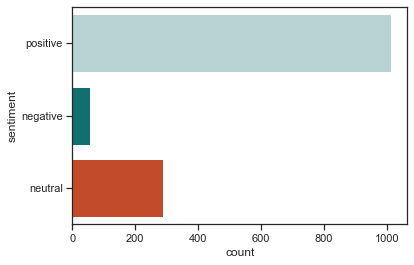

In [329]:
sns.countplot(y='sentiment', 
             data=df, 
             palette=['#b2d8d8',"#008080", '#db3d13']
             );

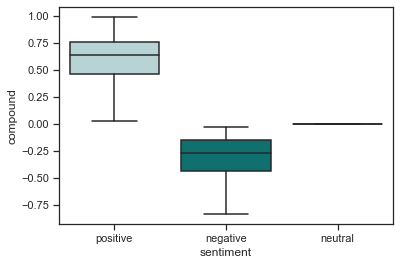

In [330]:
sns.boxplot(y='compound', 
            x='sentiment',
            palette=['#b2d8d8',"#008080", '#db3d13'], 
            data=df);

In [331]:
WR.to_excel('Word_top_200_sw.xlsx')

NameError: name 'WR' is not defined

In [332]:
#social network
cleaned_text = df['text_string_lem']
cleaned_text.reset_index(inplace=True, drop=True) # 인덱스 초기화

In [333]:
tokenizer = RegexpTokenizer('[\w]+')

count = {} # 동시출현 빈도가 저장될 dict

for line in cleaned_text:
    words = line
    tokens = tokenizer.tokenize(words) # 각 리뷰를 토큰화한 뒤 리스트에 저장
    stopped_tokens = [i for i in list(set(tokens)) if not i in stopwords]
    stopped_tokens2 = [i for i in stopped_tokens if len(i)>1]
    for i,a in enumerate(stopped_tokens2):
        for b in stopped_tokens2[i+1:]:
            if a>b:
                count[b,a] = count.get((b,a),0) + 1
            else:
                count[a,b] = count.get((a,b),0) + 1
                
df1 = pd.DataFrame.from_dict(count, orient='index')

list1=[]
for i in range(len(df)):
    list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])

df2 = pd.DataFrame(list1, columns=['term1','term2','freq'])
df3 = df2.sort_values(by=['freq'], ascending=False) # freq 기준으로 내림차순 정렬
df3_nw = df3.reset_index(drop=True)

In [334]:
YT_jp_nw = nx.Graph()

# 동시출현 빈도가 1n이상인 단어들에 대해서만 중심성 계수 계산
for i in range((len(np.where(df3_nw['freq']>1)[0]))):
    YT_jp_nw.add_edge(df3_nw['term1'][i], df3_nw['term2'][i],
                  weight=int(df3_nw['freq'][i]))

dgr = nx.degree_centrality(YT_jp_nw) # 연결 중심성
btw = nx.betweenness_centrality(YT_jp_nw) # 매개 중심성
cls = nx.closeness_centrality(YT_jp_nw) # 근접 중심성
egv = nx.eigenvector_centrality(YT_jp_nw) # 고유벡터 중심성

sorted_dgr = sorted(dgr.items(), key=operator.itemgetter(1), reverse=True)
sorted_btw = sorted(btw.items(), key=operator.itemgetter(1), reverse=True)
sorted_cls = sorted(cls.items(), key=operator.itemgetter(1), reverse=True)
sorted_egv = sorted(egv.items(), key=operator.itemgetter(1), reverse=True)

print("** degree **")
for x in range(10):
    print(sorted_dgr[x])

print("** betweenness **")
for x in range(10):
    print(sorted_btw[x])
    
print("** closeness **")
for x in range(10):
    print(sorted_cls[x])

print("** eigenvector **")
for x in range(10):
    print(sorted_egv[x])

** degree **
('japan', 0.36363636363636365)
('temple', 0.2727272727272727)
('love', 0.18181818181818182)
('italy', 0.18181818181818182)
('japanese', 0.18181818181818182)
('tsukiji', 0.18181818181818182)
('innovation', 0.18181818181818182)
('definitely', 0.09090909090909091)
('know', 0.09090909090909091)
('waterfall', 0.09090909090909091)
** betweenness **
('japan', 0.2545454545454545)
('innovation', 0.21818181818181817)
('japanese', 0.18181818181818182)
('tsukiji', 0.10909090909090909)
('temple', 0.05454545454545454)
('love', 0.0)
('italy', 0.0)
('definitely', 0.0)
('know', 0.0)
('waterfall', 0.0)
** closeness **
('japan', 0.34265734265734266)
('innovation', 0.34265734265734266)
('japanese', 0.296969696969697)
('temple', 0.2727272727272727)
('love', 0.2474747474747475)
('italy', 0.2474747474747475)
('definitely', 0.2344497607655502)
('tsukiji', 0.2344497607655502)
('tokyo', 0.1781818181818182)
('know', 0.1636363636363636)
** eigenvector **
('japan', 0.6200384283272866)
('love', 0.44542

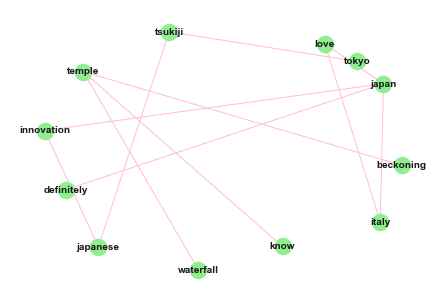

<Figure size 2e+06x2e+06 with 0 Axes>

In [335]:
nx.draw(YT_jp_nw, pos = nx.spring_layout(YT_jp_nw, k=5),
    node_color='lightgreen', linewidths=0.125, font_size=10,
    font_weight='bold', edge_color= 'pink', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

In [ ]:
nx.draw(YT_kr_nw, node_color='lightyellow', with_labels = True)

In [ ]:
nx.draw(YT_sw_nw, pos = nx.spring_layout(YT_sw_nw, k=3),
    node_color='white', linewidths=0, font_size=10, node_size = 50,
    font_weight='bold', edge_color= 'lightgrey', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

In [363]:
#LDA Topic modeling
stop_words = stopwords
vect =TfidfVectorizer(stop_words=stop_words,max_features=1000)
vect_text=vect.fit_transform(df['text_string_lem'])

In [364]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model=LatentDirichletAllocation(n_components=10,
learning_method='online',random_state=42,max_iter=1) 
lda_top=lda_model.fit_transform(vect_text)

In [365]:
print("Document : ")
for i,topic in enumerate(lda_top[0]):
  print("Topic ",i+1,": ",topic*100,"%")

Document : 
Topic  1 :  3.9645481704591132 %
Topic  2 :  3.9646051648718927 %
Topic  3 :  3.96464088330645 %
Topic  4 :  3.964847357500866 %
Topic  5 :  3.96459571670252 %
Topic  6 :  40.92591230041921 %
Topic  7 :  3.964596887841301 %
Topic  8 :  3.964749850820928 %
Topic  9 :  3.9648477485574882 %
Topic  10 :  27.35665591952024 %


In [366]:
vocab = vect.get_feature_names()
for i, comp in enumerate(lda_model.components_):
     vocab_comp = zip(vocab, comp)
     sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:10]
     print("Topic "+str(i+1)+": ")
     for t in sorted_words:
            print(t[0],end=" ")
            print('\n')

Topic 1: 
awesome 

watch 

sorry 

video 

film 

image 

high 

great 

fine 

government 

Topic 2: 
view 

best 

million 

okinawa 

style 

beat 

word 

russia 

country 

pride 

Topic 3: 
minutes 

nakagawa 

japan 

day 

goodness 

corona 

people 

know 

need 

want 

Topic 4: 
thank 

nice 

amaze 

video 

great 

wow 

japan 

wonderful 

edit 

love 

Topic 5: 
india 

girl 

person 

cake 

rice 

forever 

japan 

ruby 

wonder 

spit 

Topic 6: 
beauty 

wowmore 

hiroshima 

italy 

bold 

delicate 

expect 

japan 

wonderland 

exactly 

Topic 7: 
cool 

see 

cry 

like 

video 

japan 

introduce 

mochi 

youtu 

camera 

Topic 8: 
japanese 

proud 

learn 

bangladesh 

everything 

nara 

job 

perfect 

japan 

awesome 

Topic 9: 
beautiful 

japan 

video 

music 

like 

song 

good 

glad 

bear 

know 

Topic 10: 
japan 

love 

want 

country 

like 

visit 

video 

live 

know 

beautiful 

